In [1]:
import os
import numpy as np
import torch
import datasets
from datasets import load_dataset, Audio
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, TrainingArguments, Trainer
import evaluate

# Check Device
print("="*60)
print(" CUDA/GPU Configuration")
print("="*60)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Capability: {torch.cuda.get_device_capability(0)}")
    device = "cuda"
    print(f" Using GPU for training!")
else:
    print(" CUDA NOT available - PyTorch needs to be reinstalled with CUDA support!")
    device = "cpu"
    print(f"  WARNING: Training on CPU will be extremely slow!")

print("="*60)

 CUDA/GPU Configuration
PyTorch version: 2.5.1+cu121
CUDA available: True
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
GPU Memory: 4.29 GB
CUDA Capability: (8, 6)
 Using GPU for training!


### 1. Configuration

In [2]:
MODEL_CHECKPOINT = "facebook/wav2vec2-base"
DATASET_PATH = "../DATASET_LABELED" 
BATCH_SIZE = 4      # Giảm xuống 4 để tránh MemoryError
LEARNING_RATE = 2e-5
NUM_EPOCHS = 20
MAX_DURATION = 3.0  # Giảm xuống 3.0s để tiết kiệm RAM
SAMPLE_RATIO = 1.0

### 2. Load Dataset


In [3]:
# Load dataset from folder structure
dataset = load_dataset("audiofolder", data_dir=DATASET_PATH)

# Sample dataset nếu muốn train nhanh cho testing
if SAMPLE_RATIO < 1.0:
    dataset = dataset["train"].train_test_split(train_size=SAMPLE_RATIO, seed=42)
    dataset = dataset["train"]
    print(f"⚡ Using {SAMPLE_RATIO*100}% of dataset for faster training")
else:
    dataset = dataset["train"]

# Split into Train and Test
dataset = dataset.train_test_split(test_size=0.2, seed=42)

print("Dataset Structure:", dataset)
print("Labels:", dataset["train"].features["label"].names)

labels = dataset["train"].features["label"].names
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

Resolving data files:   0%|          | 0/1678 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset Structure: DatasetDict({
    train: Dataset({
        features: ['audio', 'label'],
        num_rows: 1342
    })
    test: Dataset({
        features: ['audio', 'label'],
        num_rows: 336
    })
})
Labels: ['ANG', 'ANX', 'HAP', 'NEU', 'SAD']


### 3. Preprocessing

In [4]:
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_CHECKPOINT)

def preprocess_function(examples):
    audio_arrays = [x["array"] for x in examples["audio"]]
    inputs = feature_extractor(
        audio_arrays, 
        sampling_rate=feature_extractor.sampling_rate, 
        max_length=int(feature_extractor.sampling_rate * MAX_DURATION), 
        truncation=True,
        padding="max_length",
        return_tensors="np"  # Return numpy arrays để tránh memory error
    )
    return inputs

# Resample audio to 16kHz (WavLM requirement)
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

# Apply preprocessing với batch_size nhỏ để tránh memory error
columns_to_remove = [col for col in dataset["train"].column_names if col != "label"]
encoded_dataset = dataset.map(
    preprocess_function, 
    batched=True,
    batch_size=32,  # Giảm batch size preprocessing xuống 32
    num_proc=1, 
    remove_columns=columns_to_remove,
    desc="Preprocessing audio"
)

# Fix label dtype: Convert labels from int32 to int64 (Long) for PyTorch
encoded_dataset = encoded_dataset.with_format("torch")

print("Preprocessing complete.")

e:\anaconda3\envs\ser\lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Preprocessing audio:   0%|          | 0/1342 [00:00<?, ? examples/s]

Preprocessing audio:   0%|          | 0/336 [00:00<?, ? examples/s]

Preprocessing complete.


### 4. Metrics

In [5]:
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=eval_pred.label_ids)

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# Tính class weights từ training data
train_labels = encoded_dataset["train"]["label"].numpy()
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Chuyển thành dictionary để dễ sử dụng
CLASS_WEIGHTS = {i: weight for i, weight in enumerate(class_weights_array)}

print("="*60)
print("Class Distribution & Weights")
print("="*60)
for i, label in enumerate(labels):
    count = (train_labels == i).sum()
    percentage = count / len(train_labels) * 100
    print(f"{label:15s}: {count:4d} samples ({percentage:5.2f}%) - Weight: {CLASS_WEIGHTS[i]:.4f}")
print("="*60)

Class Distribution & Weights
ANG            :  238 samples (17.73%) - Weight: 1.1277
ANX            :  169 samples (12.59%) - Weight: 1.5882
HAP            :  175 samples (13.04%) - Weight: 1.5337
NEU            :  610 samples (45.45%) - Weight: 0.4400
SAD            :  150 samples (11.18%) - Weight: 1.7893


### 4.5. Calculate Class Weights

### 5. Initialize Model

In [7]:
model = AutoModelForAudioClassification.from_pretrained(
    MODEL_CHECKPOINT, 
    num_labels=len(labels),
    label2id=label2id,
    id2label=id2label,
    use_safetensors=True  
)
model.to(device)

e:\anaconda3\envs\ser\lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)


### 6. Training

In [8]:
training_args = TrainingArguments(
    output_dir="./wavlm_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=8,  # Tăng lên 8 để effective batch = 4*8 = 32
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    warmup_ratio=0.15,
    warmup_steps=100,
    logging_steps=10,
    fp16=True if torch.cuda.is_available() else False,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    dataloader_num_workers=0,  # Tắt workers để tránh MemoryError
    dataloader_pin_memory=False,  # Tắt pin_memory
    optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
    gradient_checkpointing=False,
    tf32=True if torch.cuda.is_available() else False,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
)

# Custom Trainer với class weights
from torch import nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Weighted cross entropy loss
        loss_fct = nn.CrossEntropyLoss(weight=torch.tensor(list(CLASS_WEIGHTS.values()), 
                                                           device=labels.device, dtype=torch.float32))
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["test"],
    tokenizer=feature_extractor,
    compute_metrics=compute_metrics,
)

print("Starting training with improvements...")
print(f"- Duration: {MAX_DURATION}s (more context)")
print(f"- Epochs: {NUM_EPOCHS} (with early stopping)")
print(f"- Class weights: Applied to handle imbalance")
print(f"- Total steps: {len(encoded_dataset['train']) // (BATCH_SIZE * training_args.gradient_accumulation_steps) * NUM_EPOCHS}")
print("\nThis will take ~3-4 hours. Model will auto-save best checkpoint.\n")
trainer.train()

C:\Users\PC\AppData\Local\Temp\ipykernel_12304\1793746200.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


Starting training with improvements...
- Duration: 3.0s (more context)
- Epochs: 20 (with early stopping)
- Class weights: Applied to handle imbalance
- Total steps: 820

This will take ~3-4 hours. Model will auto-save best checkpoint.



Epoch,Training Loss,Validation Loss,Accuracy
1,1.605900,1.593408,0.437500
2,1.502200,1.466198,0.556548
3,1.307100,1.348390,0.610119
4,1.219100,1.231153,0.633929
5,1.029600,1.203244,0.595238
6,0.941600,1.164220,0.636905
7,0.890800,1.197861,0.625000
8,0.803900,1.192367,0.610119
9,0.610100,1.178427,0.619048
10,0.563900,1.207421,0.636905


TrainOutput(global_step=840, training_loss=0.6704103017137164, metrics={'train_runtime': 995.667, 'train_samples_per_second': 26.957, 'train_steps_per_second': 0.844, 'total_flos': 7.3101745994112e+17, 'train_loss': 0.6704103017137164, 'epoch': 20.0})

### 7. Save Final Model

In [9]:
trainer.save_model("saved_wavlm_emotion_model_v2")
print("Model saved to 'saved_wavlm_emotion_model_v2'")

Model saved to 'saved_wavlm_emotion_model_v2'


### 8. Inference Test

In [10]:
from transformers import pipeline

classifier = pipeline("audio-classification", model="saved_wavlm_emotion_model_v2", device=0 if torch.cuda.is_available() else -1)

# Test with a sample from test set
test_file = dataset["test"][0]["audio"]["path"]
print(f"Testing file: {test_file}")

result = classifier(test_file)
print(result)

Device set to use cuda:0


Testing file: E:\KHMT\N4K2\DATN\DATASET_LABELED\NEU\0h06m02s_seg0121_part1.wav
[{'score': 0.8704680800437927, 'label': 'NEU'}, {'score': 0.04711534455418587, 'label': 'ANX'}, {'score': 0.04482630640268326, 'label': 'HAP'}, {'score': 0.022157099097967148, 'label': 'SAD'}, {'score': 0.015433130785822868, 'label': 'ANG'}]


### 9. Confusion Matrix & Classification Report

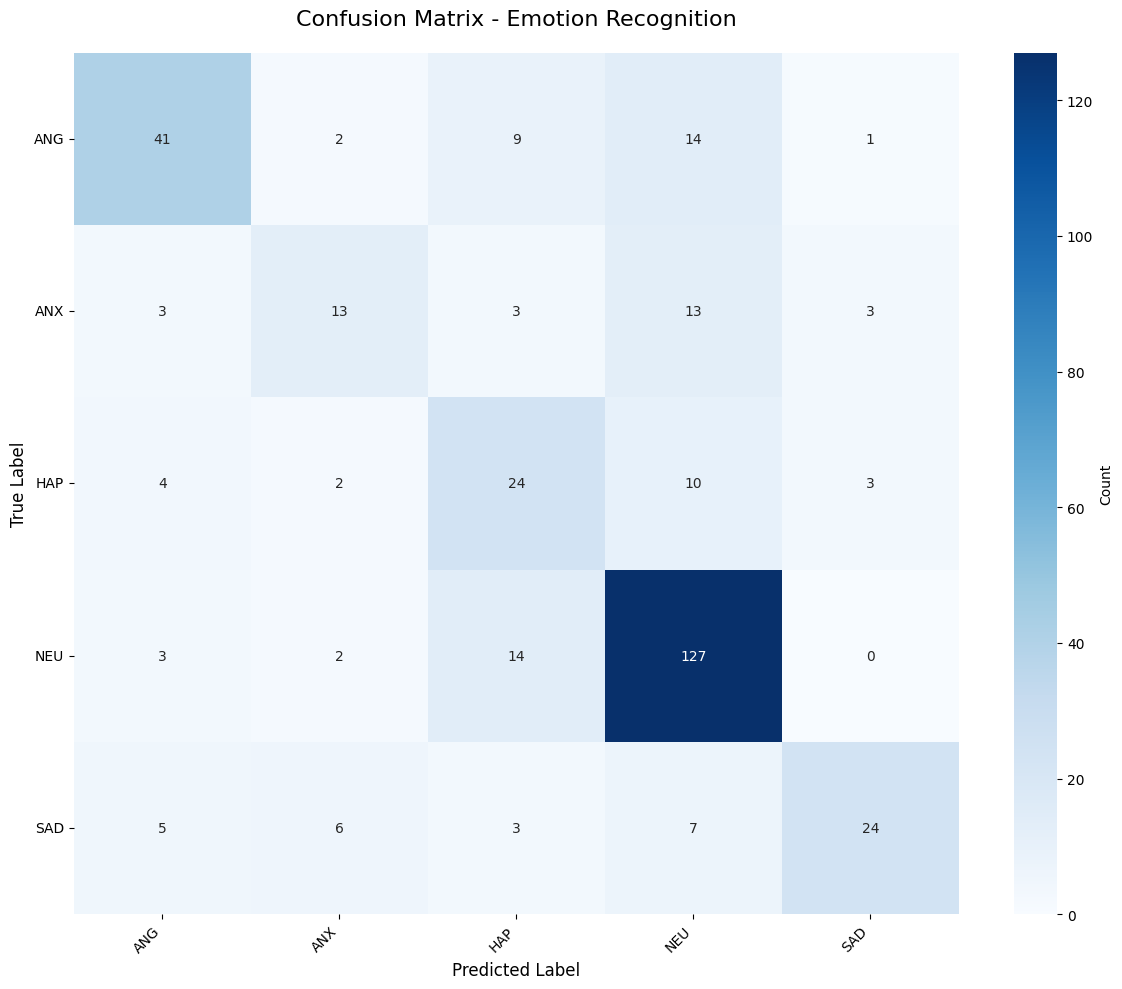


Classification Report
              precision    recall  f1-score   support

         ANG     0.7321    0.6119    0.6667        67
         ANX     0.5200    0.3714    0.4333        35
         HAP     0.4528    0.5581    0.5000        43
         NEU     0.7427    0.8699    0.8013       146
         SAD     0.7742    0.5333    0.6316        45

    accuracy                         0.6815       336
   macro avg     0.6444    0.5889    0.6066       336
weighted avg     0.6845    0.6815    0.6748       336


Per-Class Accuracy
ANG            : 61.19% (67 samples)
ANX            : 37.14% (35 samples)
HAP            : 55.81% (43 samples)
NEU            : 86.99% (146 samples)
SAD            : 53.33% (45 samples)


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Dự đoán trên toàn bộ test set
predictions = trainer.predict(encoded_dataset["test"])
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = encoded_dataset["test"]["label"].numpy()

# Tạo confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Vẽ confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Emotion Recognition', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# In classification report
print("\n" + "="*60)
print("Classification Report")
print("="*60)
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

# In accuracy theo từng class
print("\n" + "="*60)
print("Per-Class Accuracy")
print("="*60)
for i, label in enumerate(labels):
    mask = y_true == i
    if mask.sum() > 0:
        acc = (y_pred[mask] == y_true[mask]).sum() / mask.sum()
        print(f"{label:15s}: {acc*100:.2f}% ({mask.sum()} samples)")
print("="*60)

### 10. Phân Tích Chi Tiết Từng Mẫu Test

In [12]:
# Phân tích độ chính xác theo từng cảm xúc
print("="*70)
print("ĐỘ CHÍNH XÁC THEO TỪNG CẢM XÚC")
print("="*70)
print(f"{'Cảm xúc':<15} {'Số mẫu':<15} {'Dự đoán đúng':<15} {'Độ chính xác':<15}")
print("-"*70)

for i, label in enumerate(labels):
    # Lấy mask của cảm xúc này
    mask = y_true == i
    total_samples = mask.sum()
    
    if total_samples > 0:
        # Tính số dự đoán đúng
        correct_samples = (y_pred[mask] == y_true[mask]).sum()
        accuracy = correct_samples / total_samples * 100
        
        print(f"{label:<15} {total_samples:<15} {correct_samples:<15} {accuracy:.2f}%")

print("="*70)

# Tổng kết
total_correct = (y_pred == y_true).sum()
total_samples = len(y_true)
overall_accuracy = total_correct / total_samples * 100
print(f"\n📊 TỔNG KẾT: {total_correct}/{total_samples} mẫu đúng ({overall_accuracy:.2f}%)")
print("="*70)

ĐỘ CHÍNH XÁC THEO TỪNG CẢM XÚC
Cảm xúc         Số mẫu          Dự đoán đúng    Độ chính xác   
----------------------------------------------------------------------
ANG             67              41              61.19%
ANX             35              13              37.14%
HAP             43              24              55.81%
NEU             146             127             86.99%
SAD             45              24              53.33%

📊 TỔNG KẾT: 229/336 mẫu đúng (68.15%)
